In [1]:
import os
import pickle

import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    cross_val_score,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

In [2]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df=pd.read_csv('../data/train.csv')

In [4]:
df.shape

(1460, 81)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [7]:
import matplotlib.pyplot as plt

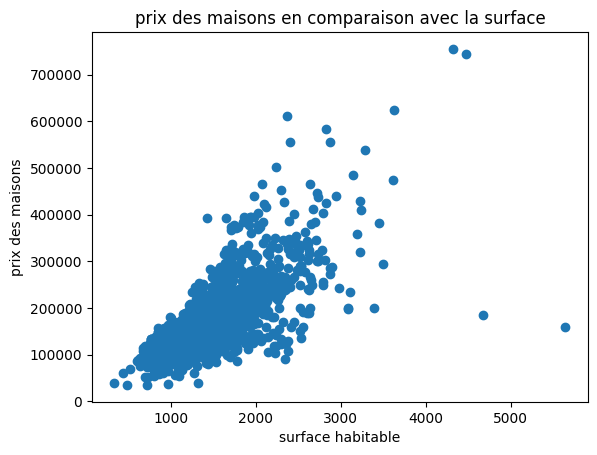

In [8]:
plt.scatter(df["GrLivArea"],df["SalePrice"])
plt.xlabel("surface habitable")
plt.ylabel("prix des maisons")
plt.title("prix des maisons en comparaison avec la surface")
plt.show()

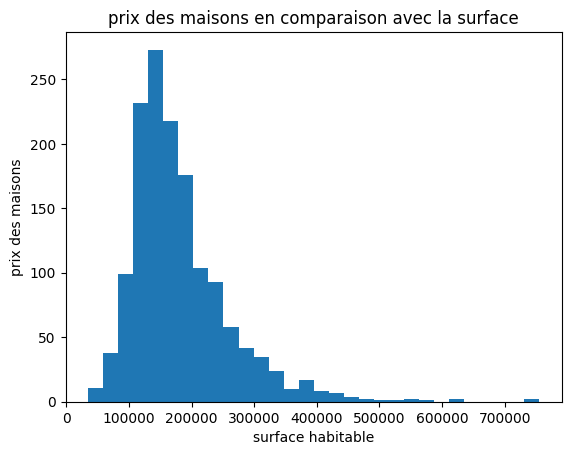

In [9]:
plt.hist(df["SalePrice"],bins=30)
plt.xlabel("surface habitable")
plt.ylabel("prix des maisons")
plt.title("prix des maisons en comparaison avec la surface")
plt.show()

In [10]:
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

In [11]:
top_features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "GarageArea",
    "TotalBsmtSF",
    "SalePrice"
]

df[top_features ].corr()

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,SalePrice
OverallQual,1.000000,0.593007,0.600671,0.562022,0.537808,0.790982
GrLivArea,0.593007,1.000000,0.467247,0.468997,0.454868,0.708624
GarageCars,0.600671,0.467247,1.000000,0.882475,0.434585,0.640409
GarageArea,0.562022,0.468997,0.882475,1.000000,0.486665,0.623431
TotalBsmtSF,0.537808,0.454868,0.434585,0.486665,1.000000,0.613581
SalePrice,0.790982,0.708624,0.640409,0.623431,0.613581,1.000000


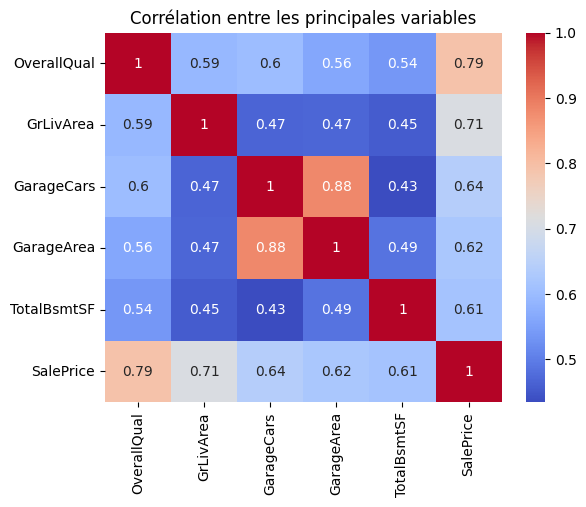

In [12]:
corr=df[top_features].corr()
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Corrélation entre les principales variables")
plt.show()

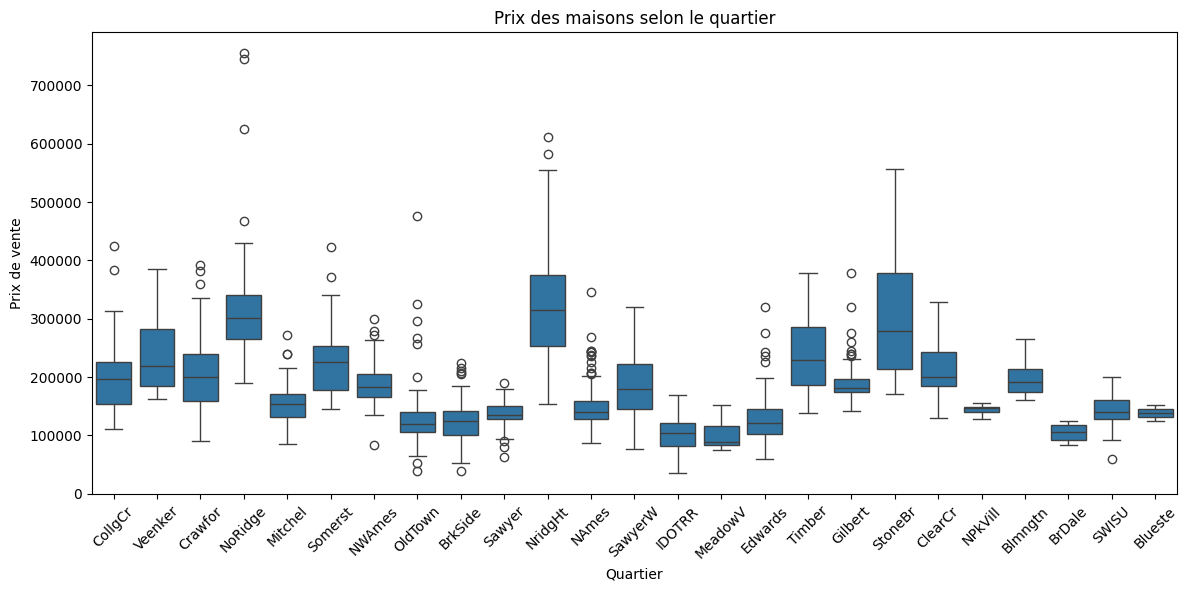

In [13]:
plt.figure(figsize=(14, 6))

sns.boxplot(x="Neighborhood", y="SalePrice", data=df)

plt.xticks(rotation=45)
plt.xlabel("Quartier")
plt.ylabel("Prix de vente")
plt.title("Prix des maisons selon le quartier")
plt.show()

In [14]:
missing=df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtFinType2      38
BsmtExposure      38
BsmtFinType1      37
BsmtCond          37
BsmtQual          37
MasVnrArea         8
Electrical         1
dtype: int64


In [15]:
missing_percent=(df.isnull().sum()/len(df))*100
missing_percent=missing_percent[missing_percent>0].sort_values(ascending=False)
print(missing_percent)

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtFinType2     2.602740
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtCond         2.534247
BsmtQual         2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64


In [16]:
df["PoolQC"].value_counts(dropna=False)

PoolQC
NaN    1453
Gd        3
Ex        2
Fa        2
Name: count, dtype: int64

In [17]:
df["PoolQC"]=df["PoolQC"].fillna("None")

In [18]:
df["PoolQC"].value_counts(dropna=False)

PoolQC
None    1453
Gd         3
Ex         2
Fa         2
Name: count, dtype: int64

In [19]:
df["LotFrontage"].isnull().sum()

259

In [20]:
df["LotFrontage"].isnull().mean() * 100

17.73972602739726

In [21]:
df["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [22]:
#median=df["LotFrontage"].median()
#df["LotFrontage"]=df["LotFrontage"].fillna(median)
#df["LotFrontage"].value_counts(dropna=False)

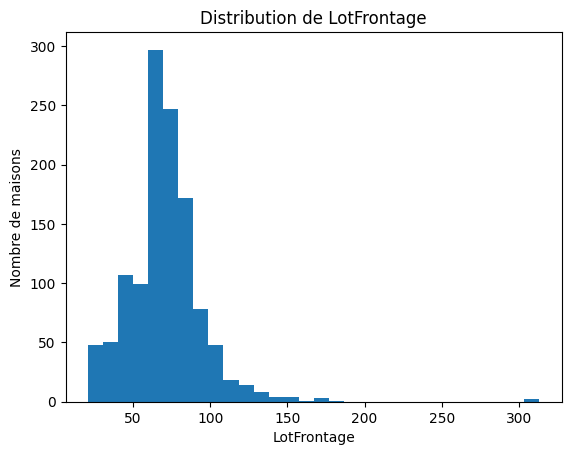

In [23]:
plt.hist(df["LotFrontage"].dropna(), bins=30)

plt.xlabel("LotFrontage")
plt.ylabel("Nombre de maisons")
plt.title("Distribution de LotFrontage")

plt.show()

In [24]:
df.groupby("Neighborhood")["LotFrontage"].median().sort_values()

Neighborhood
BrDale     21.0
MeadowV    21.0
Blueste    24.0
NPkVill    24.0
Blmngtn    43.0
BrkSide    52.0
SWISU      60.0
IDOTRR     60.0
OldTown    60.0
StoneBr    61.5
Gilbert    65.0
Edwards    65.5
SawyerW    66.5
Veenker    68.0
CollgCr    70.0
Sawyer     71.0
Mitchel    73.0
NAmes      73.0
Somerst    73.5
Crawfor    74.0
NWAmes     80.0
ClearCr    80.0
Timber     85.0
NridgHt    88.5
NoRidge    91.0
Name: LotFrontage, dtype: float64

In [25]:
df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
    lambda x: x.fillna(x.median())
)

In [26]:
df["LotFrontage"].value_counts(dropna=False)

LotFrontage
60.0     152
80.0     112
70.0      94
65.0      74
73.0      70
        ... 
137.0      1
140.0      1
38.0       1
150.0      1
46.0       1
Name: count, Length: 115, dtype: int64

In [27]:
cols_none = [
    "PoolQC",
    "MiscFeature",
    "Alley",
    "Fence",
    "FireplaceQu",
    "GarageType",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtExposure",
    "BsmtCond",
    "BsmtQual"
]

df[cols_none] = df[cols_none].fillna("None")

In [28]:
df[cols_none].isnull().sum()

PoolQC          0
MiscFeature     0
Alley           0
Fence           0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
BsmtFinType1    0
BsmtFinType2    0
BsmtExposure    0
BsmtCond        0
BsmtQual        0
dtype: int64

In [29]:
df[["MasVnrType", "MasVnrArea"]].isnull().sum()

MasVnrType    872
MasVnrArea      8
dtype: int64

In [30]:
df[df["MasVnrArea"].isnull()][["MasVnrType", "MasVnrArea"]]

,MasVnrType,MasVnrArea
234,NaN,NaN
529,NaN,NaN
650,NaN,NaN
936,NaN,NaN
973,NaN,NaN
977,NaN,NaN
1243,NaN,NaN
1278,NaN,NaN


In [31]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")
df["MasVnrArea"] = df["MasVnrArea"].fillna(0)
df["GarageYrBlt"] = df["GarageYrBlt"].fillna(0)

In [32]:
missing=df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

Electrical    1
dtype: int64


In [33]:
df["Electrical"].value_counts()

Electrical
SBrkr    1334
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [34]:
df["Electrical"] = df["Electrical"].fillna(df["Electrical"].mode()[0])

In [35]:
df["Electrical"].value_counts()

Electrical
SBrkr    1335
FuseA      94
FuseF      27
FuseP       3
Mix         1
Name: count, dtype: int64

In [36]:
num_cols=df.select_dtypes(include="number").columns
num_cols

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

In [37]:
df["GrLivArea"].describe()

count    1460.000000
mean     1515.463699
std       525.480383
min       334.000000
25%      1129.500000
50%      1464.000000
75%      1776.750000
max      5642.000000
Name: GrLivArea, dtype: float64

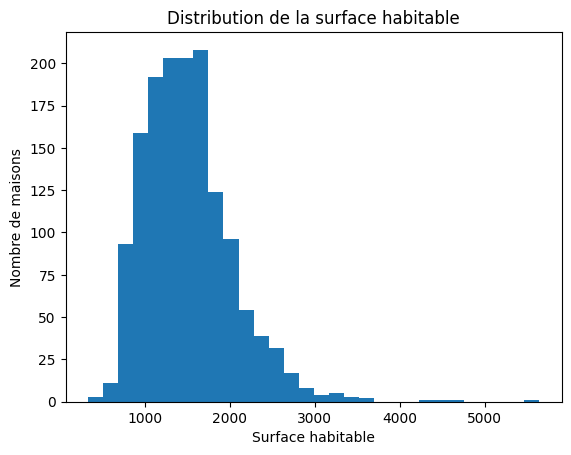

In [38]:
plt.hist(df["GrLivArea"], bins=30)

plt.xlabel("Surface habitable")
plt.ylabel("Nombre de maisons")
plt.title("Distribution de la surface habitable")

plt.show()

In [39]:
df["LotArea"].describe()

count      1460.000000
mean      10516.828082
std        9981.264932
min        1300.000000
25%        7553.500000
50%        9478.500000
75%       11601.500000
max      215245.000000
Name: LotArea, dtype: float64

Text(0.5, 1.0, 'nombre de maisons par lot area')

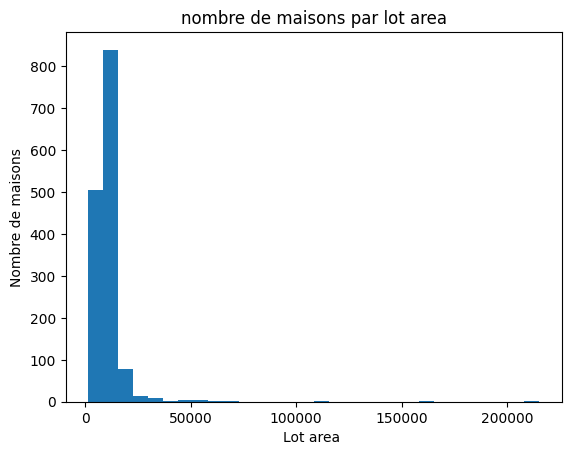

In [40]:
plt.hist(df["LotArea"],bins=30)
plt.xlabel("Lot area ")
plt.ylabel("Nombre de maisons")
plt.title("nombre de maisons par lot area")

In [41]:
df["OverallQual"].describe()

count    1460.000000
mean        6.099315
std         1.382997
min         1.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: OverallQual, dtype: float64

Text(0.5, 1.0, 'nombre de maisons par lot area')

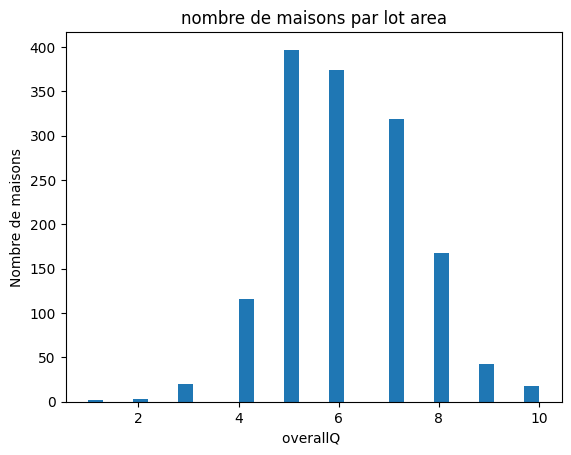

In [42]:
plt.hist(df["OverallQual"],bins=30)
plt.xlabel("overallQ ")
plt.ylabel("Nombre de maisons")
plt.title("nombre de maisons par lot area")

In [43]:
df["YearBuilt"].describe()

count    1460.000000
mean     1971.267808
std        30.202904
min      1872.000000
25%      1954.000000
50%      1973.000000
75%      2000.000000
max      2010.000000
Name: YearBuilt, dtype: float64

Text(0.5, 1.0, 'nombre de maisons par YearBuilt')

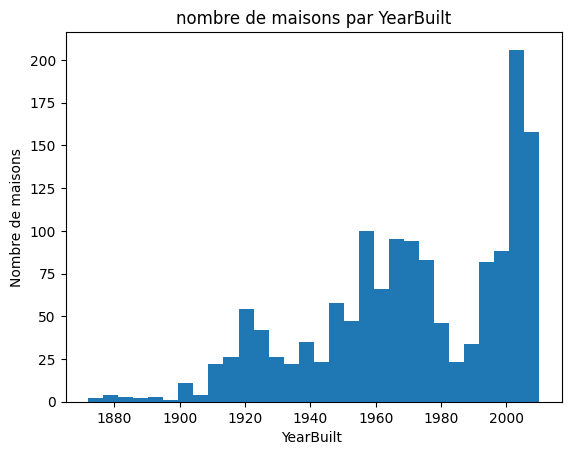

In [44]:
plt.hist(df["YearBuilt"],bins=30)
plt.xlabel("YearBuilt ")
plt.ylabel("Nombre de maisons")
plt.title("nombre de maisons par YearBuilt")

In [45]:
df["TotalBsmtSF"].describe()

count    1460.000000
mean     1057.429452
std       438.705324
min         0.000000
25%       795.750000
50%       991.500000
75%      1298.250000
max      6110.000000
Name: TotalBsmtSF, dtype: float64

Text(0.5, 1.0, 'nombre de maisons par TotalBsmtSF')

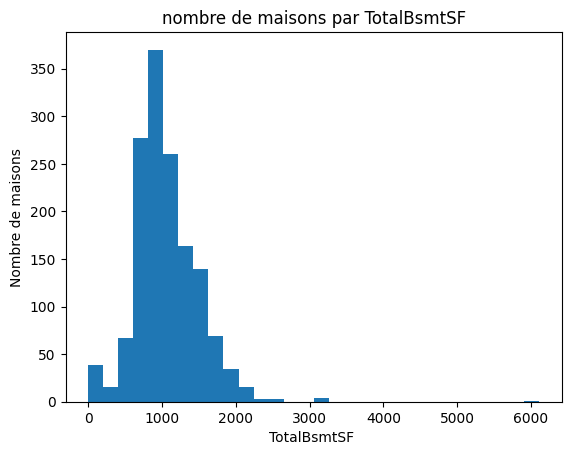

In [46]:
plt.hist(df["TotalBsmtSF"],bins=30)
plt.xlabel("TotalBsmtSF ")
plt.ylabel("Nombre de maisons")
plt.title("nombre de maisons par TotalBsmtSF")

In [47]:
df["GarageArea"].describe()

count    1460.000000
mean      472.980137
std       213.804841
min         0.000000
25%       334.500000
50%       480.000000
75%       576.000000
max      1418.000000
Name: GarageArea, dtype: float64

Text(0.5, 1.0, 'nombre de maisons par GarageArea')

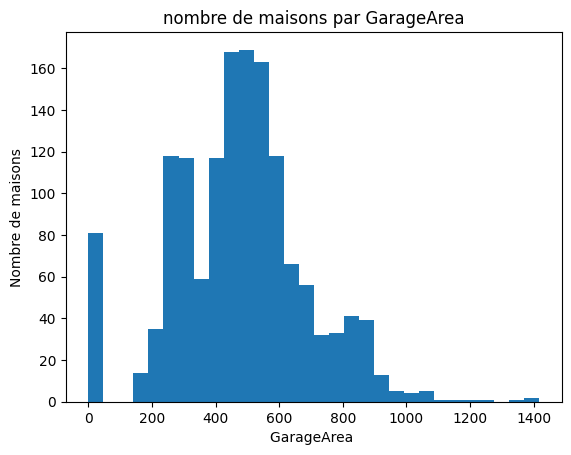

In [48]:
plt.hist(df["GarageArea"],bins=30)
plt.xlabel("GarageArea ")
plt.ylabel("Nombre de maisons")
plt.title("nombre de maisons par GarageArea")

In [49]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Text(0.5, 1.0, 'nombre de maisons par SalePrice')

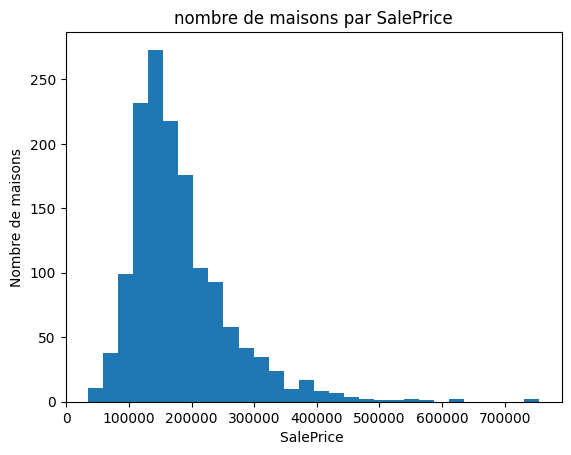

In [50]:
plt.hist(df["SalePrice"],bins=30)
plt.xlabel("SalePrice ")
plt.ylabel("Nombre de maisons")
plt.title("nombre de maisons par SalePrice")

In [51]:
num_categories=df.select_dtypes(include="object").columns
num_categories

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')

In [52]:
df["MSZoning"].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

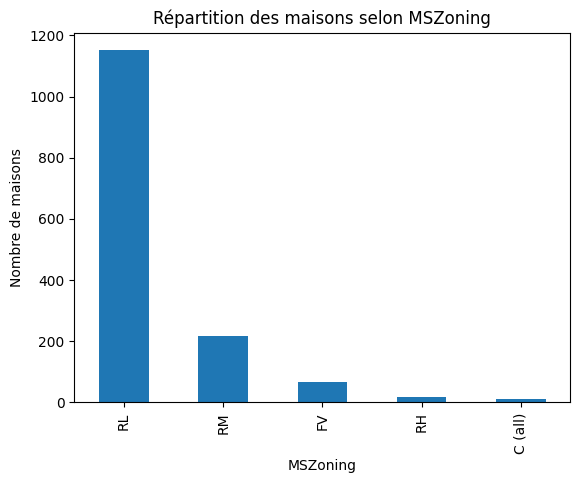

In [53]:
df["MSZoning"].value_counts().plot(kind="bar")

plt.xlabel("MSZoning")
plt.ylabel("Nombre de maisons")
plt.title("Répartition des maisons selon MSZoning")
plt.show()

In [54]:
df.groupby("MSZoning")["SalePrice"].mean()

MSZoning
C (all)     74528.000000
FV         214014.061538
RH         131558.375000
RL         191004.994787
RM         126316.830275
Name: SalePrice, dtype: float64

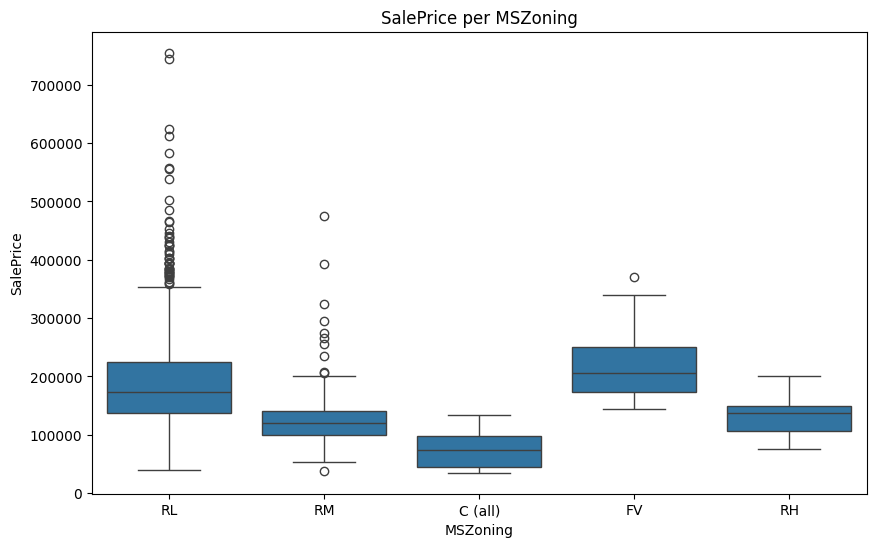

In [55]:
plt.figure(figsize=(10,6))
sns.boxplot(x="MSZoning",y="SalePrice",data=df)
plt.xlabel("MSZoning")
plt.ylabel("SalePrice")
plt.title("SalePrice per MSZoning")
plt.show()

In [56]:
df.groupby("Neighborhood")["SalePrice"].mean()

Neighborhood
Blmngtn    194870.882353
Blueste    137500.000000
BrDale     104493.750000
BrkSide    124834.051724
ClearCr    212565.428571
CollgCr    197965.773333
Crawfor    210624.725490
Edwards    128219.700000
Gilbert    192854.506329
IDOTRR     100123.783784
MeadowV     98576.470588
Mitchel    156270.122449
NAmes      145847.080000
NPkVill    142694.444444
NWAmes     189050.068493
NoRidge    335295.317073
NridgHt    316270.623377
OldTown    128225.300885
SWISU      142591.360000
Sawyer     136793.135135
SawyerW    186555.796610
Somerst    225379.837209
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64

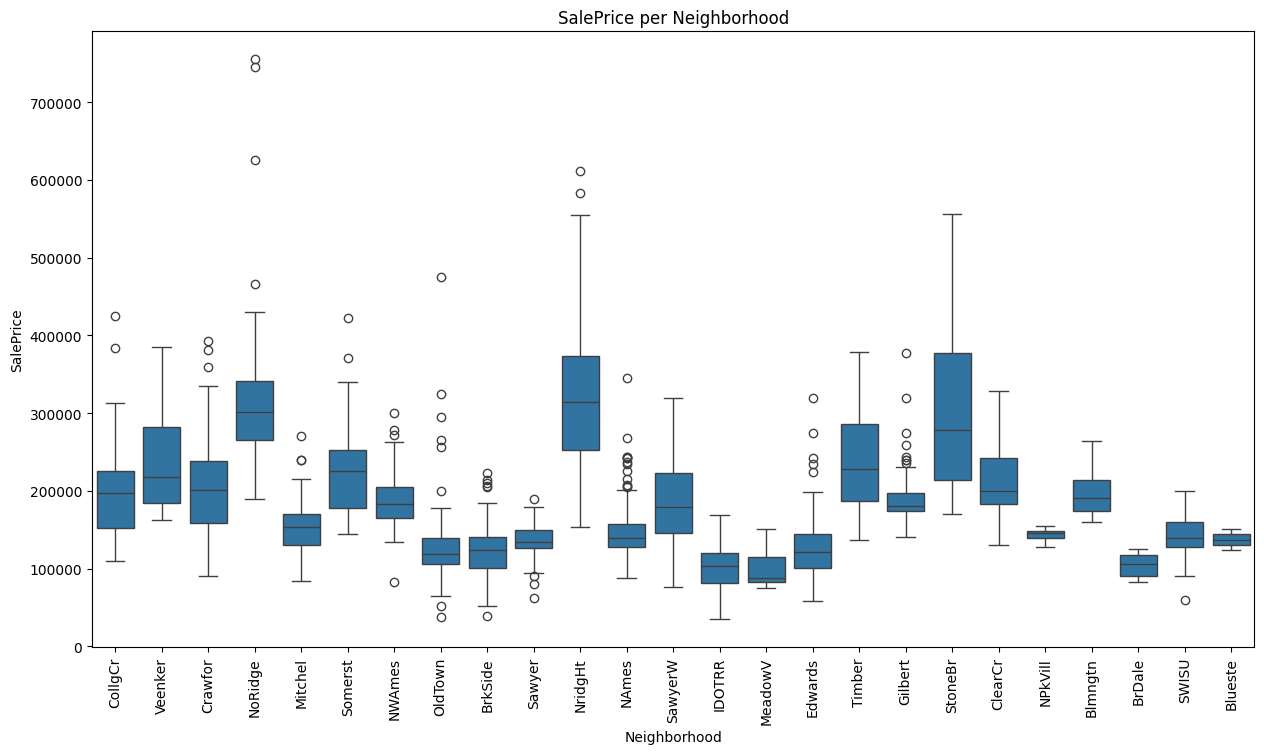

In [57]:
plt.figure(figsize=(15,8))
sns.boxplot(x="Neighborhood",y="SalePrice",data=df)
plt.xlabel("Neighborhood")
plt.xticks(rotation=90) 
plt.ylabel("SalePrice")
plt.title("SalePrice per Neighborhood")
plt.show()

In [58]:
Q1 = df["GrLivArea"].quantile(0.25)
Q3 = df["GrLivArea"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)
print("Lower :", lower)
print("Upper :", upper)

Q1 : 1129.5
Q3 : 1776.75
IQR : 647.25
Lower : 158.625
Upper : 2747.625


In [59]:
outliers = df[
    (df["GrLivArea"] < lower) |
    (df["GrLivArea"] > upper)
]

print(outliers[["GrLivArea", "SalePrice"]])

      GrLivArea  SalePrice
58         2945     438780
118        3222     320000
185        3608     475000
197        3112     235000
231        2794     403000
304        3493     295000
324        2978     242000
496        3228     430000
523        4676     184750
583        2775     325000
608        3194     359100
635        3395     200000
691        4316     755000
769        3279     538000
798        3140     485000
803        2822     582933
961        2872     272000
1024       2898     287000
1031       3082     197000
1046       2868     556581
1142       2828     424870
1169       3627     625000
1173       3086     200500
1175       2872     285000
1182       4476     745000
1268       3447     381000
1298       5642     160000
1312       2810     302000
1328       2792     256000
1353       3238     410000
1386       2784     250000


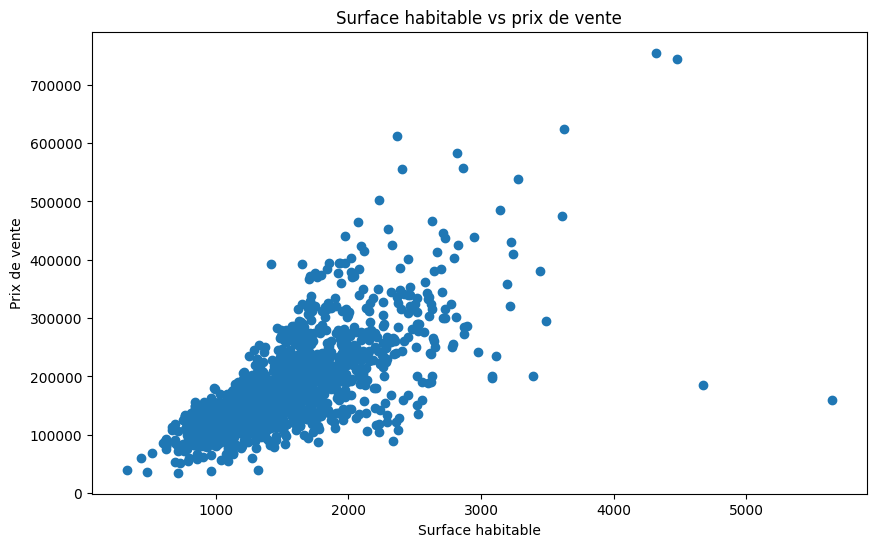

In [60]:
plt.figure(figsize=(10, 6))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("Surface habitable")
plt.ylabel("Prix de vente")
plt.title("Surface habitable vs prix de vente")

plt.show()

In [61]:
outliers.sort_values("GrLivArea", ascending=False)[
    ["GrLivArea", "SalePrice", "OverallQual", "Neighborhood", "YearBuilt"]
]

,GrLivArea,SalePrice,OverallQual,Neighborhood,YearBuilt
1298,5642,160000,10,Edwards,2008
523,4676,184750,10,Edwards,2007
1182,4476,745000,10,NoRidge,1996
691,4316,755000,10,NoRidge,1994
1169,3627,625000,10,NoRidge,1995
185,3608,475000,10,OldTown,1892
304,3493,295000,7,OldTown,1880
1268,3447,381000,8,Crawfor,1935
635,3395,200000,6,SWISU,1914
769,3279,538000,8,StoneBr,2003


In [62]:
df = df.drop(index=[523, 1298])

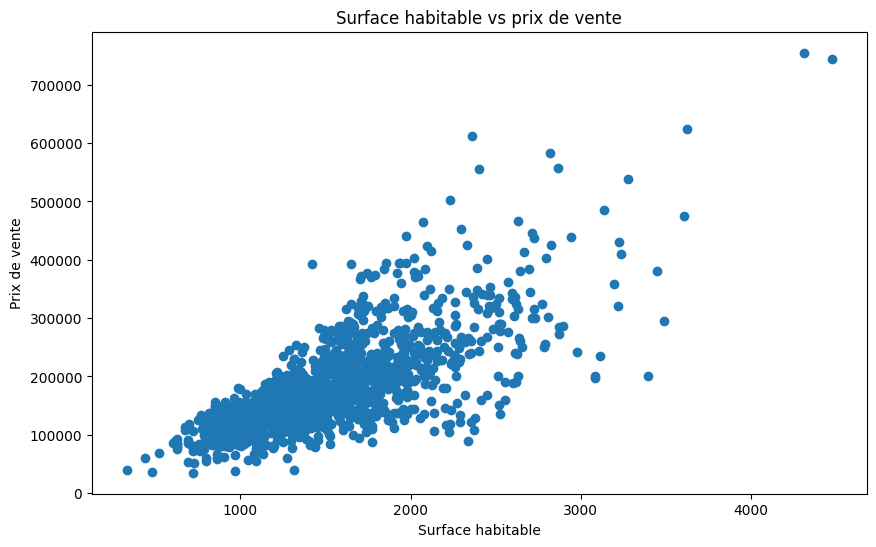

In [63]:
plt.figure(figsize=(10, 6))

plt.scatter(df["GrLivArea"], df["SalePrice"])

plt.xlabel("Surface habitable")
plt.ylabel("Prix de vente")
plt.title("Surface habitable vs prix de vente")

plt.show()

In [64]:
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

In [65]:
df[["TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "TotalSF", "SalePrice"]].head()

,TotalBsmtSF,1stFlrSF,2ndFlrSF,TotalSF,SalePrice
0,856,856,854,2566,208500
1,1262,1262,0,2524,181500
2,920,920,866,2706,223500
3,756,961,756,2473,140000
4,1145,1145,1053,3343,250000


In [66]:
df[["TotalSF", "SalePrice"]].corr()

,TotalSF,SalePrice
TotalSF,1.000000,0.832877
SalePrice,0.832877,1.000000


In [67]:
df["TotalBathrooms"] = (
    df["FullBath"]
    + 0.5 * df["HalfBath"]
    + df["BsmtFullBath"]
    + 0.5 * df["BsmtHalfBath"]
)

In [68]:
df[["TotalBathrooms", "SalePrice"]].corr()

,TotalBathrooms,SalePrice
TotalBathrooms,1.000000,0.635896
SalePrice,0.635896,1.000000


In [69]:
df["TotalPorchSF"] = (
    df["OpenPorchSF"]
    + df["3SsnPorch"]
    + df["EnclosedPorch"]
    + df["ScreenPorch"]
    + df["WoodDeckSF"]
)

In [70]:
df[["TotalPorchSF", "SalePrice"]].corr()

,TotalPorchSF,SalePrice
TotalPorchSF,1.000000,0.392897
SalePrice,0.392897,1.000000


In [71]:
df["HouseAge"] = df["YrSold"] - df["YearBuilt"]

In [72]:
df[["YearBuilt", "YrSold", "HouseAge", "SalePrice"]].head()

,YearBuilt,YrSold,HouseAge,SalePrice
0,2003,2008,5,208500
1,1976,2007,31,181500
2,2001,2008,7,223500
3,1915,2006,91,140000
4,2000,2008,8,250000


In [73]:
df[["HouseAge", "SalePrice"]].corr()

,HouseAge,SalePrice
HouseAge,1.000000,-0.524067
SalePrice,-0.524067,1.000000


In [74]:
df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

In [75]:
df[["YearRemodAdd", "YrSold", "RemodAge", "SalePrice"]].head()

,YearRemodAdd,YrSold,RemodAge,SalePrice
0,2003,2008,5,208500
1,1976,2007,31,181500
2,2002,2008,6,223500
3,1970,2006,36,140000
4,2000,2008,8,250000


In [76]:
df[["RemodAge", "SalePrice"]].corr()

,RemodAge,SalePrice
RemodAge,1.000000,-0.509706
SalePrice,-0.509706,1.000000


In [77]:
df["OverallQual_GrLivArea"] = (
    df["OverallQual"] * df["GrLivArea"]
)

In [78]:
df[["OverallQual_GrLivArea", "SalePrice"]].corr()

,OverallQual_GrLivArea,SalePrice
OverallQual_GrLivArea,1.000000,0.874116
SalePrice,0.874116,1.000000


In [79]:
df["OverallQual_TotalSF"] = (
    df["OverallQual"] * df["TotalSF"]
)

In [80]:
df[["OverallQual_TotalSF", "SalePrice"]].corr()

,OverallQual_TotalSF,SalePrice
OverallQual_TotalSF,1.00000,0.91899
SalePrice,0.91899,1.00000


In [81]:
y=df["SalePrice"]
x=df.drop("SalePrice",axis=1)
x= x.drop("Id", axis=1)
x["MSSubClass"] = x["MSSubClass"].astype(str)

In [82]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1458 entries, 0 to 1459
Data columns (total 86 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   MSSubClass             1458 non-null   object 
 1   MSZoning               1458 non-null   object 
 2   LotFrontage            1458 non-null   float64
 3   LotArea                1458 non-null   int64  
 4   Street                 1458 non-null   object 
 5   Alley                  1458 non-null   object 
 6   LotShape               1458 non-null   object 
 7   LandContour            1458 non-null   object 
 8   Utilities              1458 non-null   object 
 9   LotConfig              1458 non-null   object 
 10  LandSlope              1458 non-null   object 
 11  Neighborhood           1458 non-null   object 
 12  Condition1             1458 non-null   object 
 13  Condition2             1458 non-null   object 
 14  BldgType               1458 non-null   object 
 15  HouseStyl

In [83]:
x_train,x_validation,y_train,y_validation=train_test_split(x,y,test_size=0.2,random_state=42)

In [84]:
numeric_features=x_train.select_dtypes(include=["int64","float64"]).columns

In [85]:
categorical_features=x_train.select_dtypes(include=["object"]).columns

In [86]:
encoder=OneHotEncoder(handle_unknown="ignore")

In [87]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num","passthrough",numeric_features),
        ("cat",encoder,categorical_features)
    ]
)

In [88]:
x_train_transformed = preprocessor.fit_transform(x_train)

x_test_transformed = preprocessor.transform(x_validation)

print("Train :", x_train_transformed.shape)
print("Test  :", x_test_transformed.shape)

print(
    "Nombre de features du preprocessor :",
    len(preprocessor.get_feature_names_out())
)

print(preprocessor.get_feature_names_out()[:20])

Train : (1166, 319)
Test  : (292, 319)
Nombre de features du preprocessor : 319
['num__LotFrontage' 'num__LotArea' 'num__OverallQual' 'num__OverallCond'
 'num__YearBuilt' 'num__YearRemodAdd' 'num__MasVnrArea' 'num__BsmtFinSF1'
 'num__BsmtFinSF2' 'num__BsmtUnfSF' 'num__TotalBsmtSF' 'num__1stFlrSF'
 'num__2ndFlrSF' 'num__LowQualFinSF' 'num__GrLivArea' 'num__BsmtFullBath'
 'num__BsmtHalfBath' 'num__FullBath' 'num__HalfBath' 'num__BedroomAbvGr']


In [89]:
baseline = DummyRegressor(strategy="mean")

baseline.fit(x_train_transformed, y_train)

y_pred_baseline = baseline.predict(x_test_transformed)

In [90]:
rmse_baseline = np.sqrt(
    mean_squared_error(y_validation, y_pred_baseline)
)

mae_baseline = mean_absolute_error(
    y_validation,
    y_pred_baseline
)

r2_baseline = r2_score(
    y_validation,
    y_pred_baseline
)

print("Baseline")
print("RMSE :", rmse_baseline)
print("MAE  :", mae_baseline)
print("R²   :", r2_baseline)

Baseline
RMSE : 74323.78700238478
MAE  : 57979.83398341127
R²   : -5.394110614864722e-05


In [93]:
os.makedirs('../models',exist_ok=True)
with open ("../models/baseline.pkl","wb") as f:
    pickle.dump(baseline,f)

In [95]:
os.makedirs("../reports", exist_ok=True)

with open("../reports/module-1.md", "w") as f:
    f.write("# Module 1 — Report\n\n")
    f.write("## Baseline metrics\n\n")
    f.write(f"- Validation RMSE: {rmse_baseline:.2f}\n")
    f.write(f"- Validation MAE: {mae_baseline:.2f}\n")

In [96]:
       #        MODÈLE TROP COMPLEXE
       #                ↑
       # max_depth ↑
       # min_samples_leaf ↓
       # min_samples_split ↓
       #                │
       #                │
       #        équilibre recherché
       #                │
       #                ↓
       #        BONNE GÉNÉRALISATION
       #                │
       #                │
       # max_depth ↓
       # min_samples_leaf ↑
       # min_samples_split ↑
       #                ↓
       #        MODÈLE TROP SIMPLE

In [97]:
# Random Forest
# │
# ├── n_estimators
# │      → nombre d'arbres
# │
# ├── max_depth
# │      → profondeur maximale des arbres
# │
# ├── min_samples_split
# │      → minimum d'observations pour diviser un nœud
# │
# ├── min_samples_leaf
# │      → minimum d'observations dans une feuille
# │
# └── max_features
#        → nombre de features considérées lors des splits

In [98]:
# GridSearchCV: Au lieu de faire manuellement :

# essai 1
# essai 2
# essai 3
# essai 4
# ...

# on peut donner une grille à sklearn :
# GridSearchCV
#       ↓
# essaie les combinaisons
#       ↓
# Cross-Validation pour chaque combinaison
#       ↓
# calcule le RMSE
#       ↓
# compare
#       ↓
# meilleure configuration

# si on met trop de valeurs dans la grille, le nombre d'entraînements explose.

In [99]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_transformed, y_train)

y_pred_rf = rf.predict(x_test_transformed)

rmse_rf = np.sqrt(mean_squared_error(y_validation, y_pred_rf))
mae_rf = mean_absolute_error(y_validation, y_pred_rf)
r2_rf = r2_score(y_validation, y_pred_rf)

print("Random Forest")
print("RMSE :", rmse_rf)
print("MAE  :", mae_rf)
print("R²   :", r2_rf)

Random Forest
RMSE : 25510.848662234
MAE  : 16688.450684931504
R²   : 0.882180390660249


In [100]:

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    rf,
    x_train_transformed,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

rmse_scores = -scores

print("RMSE par fold :", rmse_scores)
print("RMSE moyen :", rmse_scores.mean())
print("Écart-type :", rmse_scores.std())

RMSE par fold : [30663.65127976 27087.44613844 25468.60523084 24394.25310141
 24013.10339281]
RMSE moyen : 26325.411828654054
Écart-type : 2417.0759070744552


In [ ]:
param_grid = {
    "n_estimators": [100,150,180, 200],
    "max_depth": [None, 8,2,5],
    "min_samples_leaf": [1, 2,3,4]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=3
)

grid_search.fit(x_train_transformed, y_train)
print("TERMINÉ")

Fitting 5 folds for each of 64 candidates, totalling 320 fits


27*5=135

In [ ]:
print("Meilleurs paramètres :")
print(grid_search.best_params_)

print("\nMeilleur RMSE CV :")
print(-grid_search.best_score_)

In [ ]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(x_train_transformed, y_train)

y_pred_gb = gb.predict(x_test_transformed)

rmse_gb = np.sqrt(mean_squared_error(y_validation, y_pred_gb))
mae_gb = mean_absolute_error(y_validation, y_pred_gb)
r2_gb = r2_score(y_validation, y_pred_gb)

print("Gradient Boosting")
print("RMSE :", rmse_gb)
print("MAE  :", mae_gb)
print("R²   :", r2_gb)

In [ ]:
scores_gb=cross_val_score(
    gb,
    x_train_transformed,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)

rmse_scores = -scores_gb

print("RMSE par fold :", rmse_scores)
print("RMSE moyen :", rmse_scores.mean())
print("Écart-type :", rmse_scores.std())
    

In [ ]:
param_grid={
    "n_estimators":[100,130,160,200],
    "max_depth":[1,3,5,10],
    "learning_rate":[0.1,0.2,0.3,0.5]
}
grid_search_gb=GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=3
)

grid_search_gb.fit(x_train_transformed, y_train)
print("Meilleurs paramètres :")
print(grid_search_gb.best_params_)

print("\nMeilleur RMSE CV :")
print(-grid_search_gb.best_score_)

In [ ]:
xgb=XGBRegressor(
     n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
xgb.fit(x_train_transformed,y_train)
y_pred_xgb=xgb.predict(x_test_transformed)
rmse_xgb=np.sqrt(mean_squared_error(y_validation,y_pred_xgb))
mae_xgb=mean_absolute_error(y_validation,y_pred_xgb)
r2_xgb=r2_score(y_validation,y_pred_xgb)

print("rmse ",rmse_xgb)
print("mae ",mae_xgb)
print("r2 ",r2_xgb)

In [ ]:
scores_xgb=cross_val_score(
    xgb,
    x_train_transformed,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)
rmse_scores = -scores_xgb

print("RMSE par fold :", rmse_scores)
print("RMSE moyen :", rmse_scores.mean())
print("Écart-type :", rmse_scores.std())

In [ ]:
grid_params={
    "n_estimators":[220,200,150,100],
    "learning_rate":[0.1,0.01,0.09,0.2],
    "max_depth":[1,2,3,4]
}
grid_xgb = GridSearchCV(
    estimator=xgb,
    param_grid=grid_params,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=3
)

grid_xgb.fit(x_train_transformed, y_train)
print("Meilleurs paramètres :", grid_xgb.best_params_)
print("Meilleur RMSE CV :", -grid_xgb.best_score_)

In [ ]:
best_gb=grid_xgb.best_estimator

In [ ]:
y_pred = best_gb.predict(x_test_transformed)
rmse = mean_squared_error(y_validation, y_pred) ** 0.5
mae = mean_absolute_error(y_validation, y_pred)
r2 = r2_score(y_validation, y_pred)

print("RMSE :", rmse)
print("MAE  :", mae)

print("R²   :", r2)

In [ ]:
errors = pd.DataFrame({
    "actual": y_validation,
    "predicted": y_pred
})

errors["error"] = errors["actual"] - errors["predicted"]
errors["abs_error"] = errors["error"].abs()
errors["percentage_error"] = (
    errors["abs_error"] / errors["actual"]
) * 100

errors.head()

In [ ]:
worst_predictions = errors.sort_values(
    "abs_error",
    ascending=False
).head(10)

worst_predictions

In [ ]:
worst_indices = errors.nlargest(10, "abs_error").index

worst_houses = df.loc[worst_indices]

worst_houses

In [ ]:
cols = [
    "OverallQual",
    "GrLivArea",
    "YearBuilt",
    "YearRemodAdd",
    "TotalBsmtSF",
    "1stFlrSF",
    "GarageCars",
    "GarageArea",
    "FullBath",
    "TotRmsAbvGrd",
    "Neighborhood",
    "SalePrice"
]

worst_houses[cols]

In [ ]:
model_final = Pipeline(
    steps=[("preprocessor", preprocessor), ("model", xgb)]
)

model_final.fit(x_train, y_train)

y_pred = model_final.predict(x_validation)

rmse_final = np.sqrt(mean_squared_error(y_validation, y_pred))
mae_final = mean_absolute_error(y_validation, y_pred)
print("RMSE :", rmse_final)
print("MAE  :", mae_final)
os.makedirs("../reports/",exist_ok=True)
with open("../reports/module-1.md","wb") as f:
    f.write("## module 1 baseline ##\n\n")
    f.write(f"- **RMSE (validation)** : {rmse_final:.2f}\n")
    f.write(f"- **MAE (validation)** : {mae_final:.2f}\n")

In [ ]:
os.makedirs("../models", exist_ok=True)

with open("../models/baseline.pkl", "wb") as f:
    pickle.dump(model_final, f)